In [1]:
from __future__ import division
from __future__ import print_function
# ---
# jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: percent
#       format_version: '1.3'
#       jupytext_version: 1.18.1
#   kernelspec:
#     display_name: Python 2
#     language: python
#     name: python2
# ---

import warnings
warnings.filterwarnings("ignore")

<h1>MIMIC Treatment Disparities, Stratified by Mistrust</h1>
The code can stand to be cleaned up to mirror the tidy-ness of race_mimic_aggressive.ipynb, but it generates the figures from the poster.

In [2]:
from __future__ import absolute_import
from future import standard_library
from six.moves import map
from six.moves import range
from six.moves import zip
standard_library.install_aliases()
from builtins import zip
from builtins import map
from builtins import str
from builtins import range
from past.utils import old_div
import psycopg2
import tqdm

# create a database connection
sqluser = 'wboag'
dbname = 'mimiciv'

# Connect to the database
# con = psycopg2.connect(dbname=dbname, user=sqluser, host="/var/run/postgresql")
con = psycopg2.connect(dbname=dbname, user=sqluser, host="host.docker.internal", port="5432")

In [3]:
# Preprocessing / Normalization

def normalize_race(race):
    if 'HISPANIC' in race:
        return 'Hispanic'
    if 'SOUTH AMERICAN' in race:
        return 'Hispanic'
    if 'AMERICAN INDIAN' in race:
        return 'Native American'
    if 'ASIAN' in race:
        return 'Asian'
    if 'BLACK' in race:
        return 'Black'
    if 'WHITE' in race:
        return 'White'
    return 'Other'

def normalize_discharge(disch):
    if not disch:
        return 'other'
    if disch.startswith('HOSPICE'):
        return 'Hospice'
    if disch == 'DEAD/EXPIRED':
        return 'Deceased'
    if disch.startswith('SNF'):
        return 'Skilled Nursing Facility'
    return 'other'

In [4]:
# Query for data

import pandas as pd
import time

print(time.strftime("%Y-%m-%d %H:%M:%s"))

# static demographic info 
# [repro] note: 
# - updated `age` to `admission_age`
# - filtered to first ICU stay only to match original behavior
demographics_query = """
SELECT DISTINCT
    subject_id,
    hadm_id,
    gender,
    CASE
      WHEN admission_age > 89 THEN 90
      ELSE ROUND(admission_age)
    END AS age,
    race AS ethnicity
FROM mimiciv_derived.icustay_detail
WHERE first_icu_stay = TRUE;
"""
demographics = pd.read_sql_query(demographics_query, con)

demographics['ethnicity'] = demographics['ethnicity'].apply(normalize_race)
demographics = demographics.rename(columns={'ethnicity':'race'})

def normalize_age(age):
    return min(age, 90)
demographics['age'] = demographics['age'].apply(normalize_age)


# admissions info
discharge_query = """
SELECT DISTINCT subject_id,hadm_id,race AS ethnicity,discharge_location,admittime,dischtime
FROM mimiciv_hosp.admissions;
"""

discharge = pd.read_sql_query(discharge_query, con)

discharge['discharge_location'] = discharge['discharge_location'].apply(normalize_discharge)

discharge['ethnicity'] = discharge['ethnicity'].apply(normalize_race)
discharge = discharge.rename(columns={'ethnicity':'race'})

print(time.strftime("%Y-%m-%d %H:%M:%s"))

discharge.head()

2025-12-04 03:41:1764819703
2025-12-04 03:41:1764819704


,subject_id,hadm_id,race,discharge_location,admittime,dischtime
0,10144093,25263721,White,Other,2182-06-10 04:44:00,2182-06-13 15:00:00
1,11018127,28420698,Black,Other,2175-11-16 13:08:00,2175-11-24 13:11:00
2,11035066,23409080,Other,Other,2121-02-21 03:33:00,2121-02-25 12:23:00
3,10840912,25267407,White,Other,2116-06-16 20:26:00,2116-06-29 16:20:00
4,10303080,21211401,White,Other,2176-08-05 17:08:00,2176-08-10 15:52:00


In [5]:
# EOL Cohort
import numpy as np

print(time.strftime("%Y-%m-%d %H:%M:%s"))

# query for discharge info
mortality_query = "SELECT DISTINCT subject_id,dod from mimiciv_hosp.patients where dod is not null;"
mortality = pd.read_sql_query(mortality_query, con)

# patients who died or went to hospice
#eol_locations = {'Hospice', 'Deceased'}
eol_locations = {'Hospice', 'Deceased', 'Skilled Nursing Facility'}
disch = discharge.loc[discharge['discharge_location'].isin(eol_locations)]

expired = pd.merge(discharge,mortality, on=['subject_id'])
expired['dod'] = pd.to_datetime(expired['dod'])
expired['dischtime'] = pd.to_datetime(expired['dischtime'])

expired['mort'] = expired['dod'] - expired['dischtime']
six_months = expired.loc[expired['mort']<=pd.Timedelta(days=360)]
in_hosp = expired.loc[expired['mort']<=pd.Timedelta(days=0)]
zero_to_six = six_months.loc[~six_months['hadm_id'].isin(in_hosp)]
one_week = expired.loc[expired['mort']<=pd.Timedelta(days=7)]

#ids =  set(six_months.hadm_id.values) | set(disch)
#ids =  set(six_months.hadm_id.values) | set(disch)
#ids =  (set(six_months.hadm_id.values) & set(disch))
#ids =  set(six_months.hadm_id.values) 
#ids =  set(in_hosp.hadm_id.values) | set(disch.hadm_id.values)
ids =  set(disch.hadm_id.values)
#ids =  set(zero_to_six.hadm_id.values) 
#ids =  set(one_week.hadm_id.values) 
#ids =  (set(zero_to_six.hadm_id.values)) & set(disch.hadm_id.values)
#ids =  (set(zero_to_six.hadm_id.values)) & set(disch.hadm_id.values)
#ids =  (set(zero_to_six.hadm_id.values))
#ids =  set(disch.hadm_id.values)
#ids =  set(disch.hadm_id.values) & set(six_months.hadm_id.values)
#eol_cohort_initial = six_months
eol_cohort_initial = discharge.loc[discharge.hadm_id.isin(ids)]

inds_at_least_6hrs = eol_cohort_initial['dischtime'] - eol_cohort_initial['admittime'] > pd.Timedelta(days=1)
eol_cohort_initial = eol_cohort_initial.loc[inds_at_least_6hrs]

# add demographics info
eol_cohort = pd.merge(eol_cohort_initial, demographics, on=['hadm_id','race'])
#eol_cohort = eol_cohort.rename(columns={'ethnicity':'race'})

# normalize columns of data
#eol_cohort['discharge_location'] = eol_cohort['discharge_location'].apply(normalize_discharge)


# make sure each hadm_id has only died once
print('eol subjects:', len(eol_cohort))
print('eol subjects:', len(set(eol_cohort['hadm_id'].values)))
assert len(eol_cohort) == len(set(eol_cohort['hadm_id'].values))

print(time.strftime("%Y-%m-%d %H:%M:%s"))

2025-12-04 03:41:1764819704
eol subjects: 2081
eol subjects: 2081
2025-12-04 03:41:1764819705


In [6]:
# Useful processing tools for treatment duration data

from collections import defaultdict

def find(groups, it):
    for i,group in enumerate(groups):
        if it in group:
            return i

def transitive_closure(items, merge):
    groups = [ [it] for it in items ]
    for a,b in merge:
        # make sure a and b are in the same group
        group_a = find(groups, a)
        group_b = find(groups, b)
        if group_a < group_b:
            group_ab = groups[group_a] + groups[group_b]
            del groups[group_b]
            del groups[group_a]
            groups.append(group_ab)
        elif group_a > group_b:
            group_ab = groups[group_a] + groups[group_b]
            del groups[group_a]
            del groups[group_b]
            groups.append(group_ab)
        else:
            # already same group
            pass
    return groups

In [7]:
# Mechanical Ventilation

import tqdm

eol_hadmids = list(map(str,set(eol_cohort['hadm_id'].values)))

# [repro] updated `ventdurations` to use ventilation_durations table
# query = \
# """
# select i.hadm_id, v.starttime, v.endtime
# FROM mimiciii.icustay_detail i
# INNER JOIN mimiciii.ventilation_durations v ON i.icustay_id = v.icustay_id
# where i.hadm_id in (%s)
# and v.starttime between intime and outtime
# and v.endtime between intime and outtime;
# """ % ','.join(eol_hadmids)
query = """
SELECT
    i.hadm_id,
    v.starttime,
    v.endtime
FROM mimiciv_derived.icustay_detail AS i
INNER JOIN mimiciv_derived.ventilation AS v
    ON i.stay_id = v.stay_id
WHERE i.hadm_id IN (%s)
  AND v.starttime BETWEEN i.icu_intime AND i.icu_outtime
  AND v.endtime   BETWEEN i.icu_intime AND i.icu_outtime;
""" % ','.join(eol_hadmids)

vent_data = pd.read_sql_query(query, con)


duration_aggregate = 'sum_spans'
vent_spans = defaultdict(list)
for hadm_id,rows in tqdm.tqdm(vent_data.groupby('hadm_id')):
    rows =  rows.sort_values('starttime')
    
    if duration_aggregate == 'max-min':
        span = rows.iloc[-1].endtime - rows.iloc[0].starttime
        assert span > pd.Timedelta(days=0)
        vent_spans[hadm_id].append(span)   
    elif duration_aggregate == 'sum_spans':
        merge = []
        for i in range(len(rows)-1):
            if rows.iloc[i+1].starttime - rows.iloc[i].endtime <= pd.Timedelta(hours=10):
                merge.append( (i,i+1) )

        for group in transitive_closure(list(range(len(rows))), merge):
            lo = min(group)
            hi = max(group)
            span = rows.iloc[hi].endtime - rows.iloc[lo].starttime
            assert span > pd.Timedelta(days=0)
            vent_spans[hadm_id].append(span)
    else:
        raise Exception('dunno!')

vent_quantity = { hadm_id:sum([ts.total_seconds()/60. for ts in timestamps]) for hadm_id,timestamps in list(vent_spans.items()) }
#vent_quantity = { hadm_id:timestamps[0].total_seconds()/60. for hadm_id,timestamps in vent_spans.items() }
#vent_quantity = { hadm_id:timestamps[-1].total_seconds()/60. for hadm_id,timestamps in vent_spans.items() }

100%|██████████| 1580/1580 [00:01<00:00, 1458.48it/s]


In [8]:
# Vasopressors

import tqdm

# [repro] updated `vasopressordurations` to use vasopressor_durations table
# Start merging all other interventions
table_names  = ['vasopressin']
column_names = ['vaso'                ]

eol_hadmids = list(map(str,set(eol_cohort['hadm_id'].values)))

vaso_quantities = defaultdict(dict)
for t, c in zip(table_names, column_names):
    print((t, c))
    # TOTAL VASOPRESSOR DATA
    query = """
    SELECT
        i.hadm_id,
        v.starttime,
        v.endtime
    FROM mimiciv_derived.icustay_detail AS i
    INNER JOIN mimiciv_derived.%s AS v
        ON i.stay_id = v.stay_id
    WHERE v.starttime BETWEEN i.icu_intime AND i.icu_outtime
    AND v.endtime   BETWEEN i.icu_intime AND i.icu_outtime
    AND i.hadm_id IN (%s);
    """ % (t, ','.join(eol_hadmids))
    vaso_data = pd.read_sql_query(query,con)
    print (vaso_data.head())

    #print time.strftime("%Y-%m-%d %H:%M:%s")

    duration_aggregate = 'sum_spans'
    vaso_spans = defaultdict(list)
    for hadm_id,rows in tqdm.tqdm(vaso_data.groupby('hadm_id')):
        rows =  rows.sort_values('starttime')

        if duration_aggregate == 'max-min':
            span = rows.iloc[-1].endtime - rows.iloc[0].starttime
            assert span >= pd.Timedelta(days=0)
            vaso_spans[hadm_id].append(span)   
        elif duration_aggregate == 'sum_spans':
            merge = []
            for i in range(len(rows)-1):
                if rows.iloc[i+1].starttime - rows.iloc[i].endtime <= pd.Timedelta(hours=10):
                    merge.append( (i,i+1) )

            for group in transitive_closure(list(range(len(rows))), merge):
                lo = min(group)
                hi = max(group)
                span = rows.iloc[hi].endtime - rows.iloc[lo].starttime
                assert span >= pd.Timedelta(days=0)
                vaso_spans[hadm_id].append(span)
        else:
            raise Exception('dunno!')
            
    vaso_quantities[c] = { hadm_id:sum([ts.total_seconds()/60. for ts in timestamps]) for hadm_id,timestamps in list(vaso_spans.items()) }
    #vaso_quantities[c] = { hadm_id:timestamps[0].total_seconds()/60. + 5 for hadm_id,timestamps in vaso_spans.items() }
    #vaso_quantities[c] = { hadm_id:timestamps[-1].total_seconds()/60. for hadm_id,timestamps in vaso_spans.items() }



('vasopressin', 'vaso')
    hadm_id           starttime             endtime
0  29458668 2150-12-24 09:23:00 2150-12-25 07:32:00
1  29458668 2150-12-25 07:32:00 2150-12-25 08:04:00
2  29234056 2155-12-24 02:15:00 2155-12-24 17:33:00
3  29232390 2119-04-30 10:45:00 2119-04-30 22:23:00
4  24221220 2125-11-24 05:22:00 2125-11-24 16:25:00


100%|██████████| 119/119 [00:00<00:00, 858.93it/s]


In [9]:
# load oasis severity scores
oasis_query = 'select hadm_id,max(oasis) as oasis from mimiciv_derived.oasis group by hadm_id'
oasis_df = pd.read_sql_query(oasis_query, con)
severities = dict(oasis_df[['hadm_id','oasis']].values)
print(len(severities))

85242


<h1>Racial Disparities in Mistrust Metrics</h1>

2025-12-04 03:41:1764819706
2025-12-04 03:41:1764819706
	white:    1445 -0.08697129553206318
	black: 224 -0.009101764689047796
	p-value: 0.02703382928992465


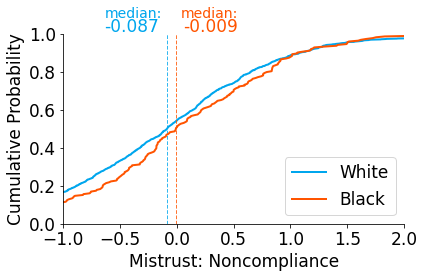

In [10]:
import pylab as pl
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu

# Mistrust scores
print(time.strftime("%Y-%m-%d %H:%M:%s"))
import pickle as pickle
with open('../data/mistrust_noncompliant.pkl', 'rb') as f:
    scores = pickle.load(f)
vals = np.array(list(scores.values()))
mu = vals.mean()
std = vals.std()
scores = {hadm_id:old_div((s-mu),std) for hadm_id,s in list(scores.items())}
print(time.strftime("%Y-%m-%d %H:%M:%s"))

# Get b/w cohorts
white_ids = set(eol_cohort.loc[eol_cohort['race']=='White'].hadm_id.values) & set(scores.keys())
black_ids = set(eol_cohort.loc[eol_cohort['race']=='Black'].hadm_id.values) & set(scores.keys())
#white_ids = set(demographics.loc[demographics['race']=='White'].hadm_id.values) & set(scores.keys())
#black_ids = set(demographics.loc[demographics['race']=='Black'].hadm_id.values) & set(scores.keys())

white_mistrust = [scores[hadm_id] for hadm_id in white_ids]
black_mistrust = [scores[hadm_id] for hadm_id in black_ids]


def list_median(vals):
    svals = sorted(vals)
    return svals[old_div(len(svals),2)]

def captialize(t):
    return ' '.join([w.capitalize() for w in t.split()])

colors = ['#00A6ED', '#FF5400']
i = 0

fig = pl.figure()

w_median = list_median(white_mistrust)
b_median = list_median(black_mistrust)
larger_median = max(w_median, b_median)

mistrusts = {'White':white_mistrust, 'Black':black_mistrust}

for demographic in ['White', 'Black']:
    vals = list(mistrusts[demographic])
    #print(len(vals))
    #print (np.sort(vals)[int(len(vals)/2)])
    pl.plot(np.sort(vals), np.linspace(0, 1, len(vals), endpoint=False), color=colors[i], label = demographic, lw=2)
    pl.xlim((-1,2))
    pl.ylim((0,1.0))

    median = np.sort(vals)[int(old_div(len(vals),2))]
    pl.axvline(x=median, linestyle="--", lw=1, color=colors[i], alpha=0.8) 
    p = 0.55
    if median == larger_median:
        h = 'right'
    else:
        p = -p
        h = 'left'
    #h = 'center'
    pl.text(x=median+p, y=1.085, horizontalalignment=h, s="median:", fontsize=14, color=colors[i])
    pl.text(x=median+p, y=1.01 , horizontalalignment=h, s=('%.3f' % median), fontsize=17, color=colors[i])

    i += 1

ax = plt.subplot(111)    
ax.spines["top"].set_visible(False)    
#ax.spines["bottom"].set_visible(False)    
ax.spines["right"].set_visible(False)    
#ax.spines["left"].set_visible(False)    
pl.yticks(fontsize=17)    
pl.xticks(fontsize=17) 

pl.legend(loc=4, fontsize=17)
pl.ylabel("Cumulative Probability", fontsize=17)
pl.xlabel("Mistrust: Noncompliance", fontsize=17)

pl.tight_layout()
pl.savefig('../images/chapter4/mistrust_noncompliant_mimic.png')

p1 = list(white_mistrust)
p2 = list(black_mistrust)
w = mannwhitneyu(p1, p2)
print('\twhite:   ', len(p1), w_median)
print('\tblack:', len(p2), b_median)
print('\tp-value:', w.pvalue)

pl.show()

2025-12-04 03:41:1764819706
2025-12-04 03:41:1764819706
	white:    1445 -0.9579246623803113
	black: 224 -0.9580631820239087
	p-value: 0.07933243581846727


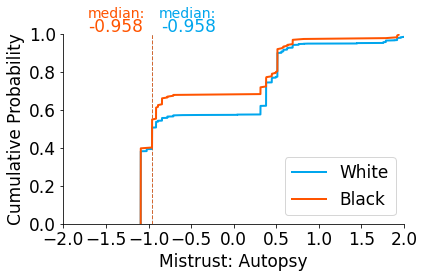

In [11]:
import pylab as pl
import numpy as np
from scipy.stats import mannwhitneyu
import random

# Mistrust scores
print(time.strftime("%Y-%m-%d %H:%M:%s"))
import pickle as pickle
with open('../data/mistrust_autopsy.pkl', 'rb') as f:
    scores = pickle.load(f)
vals = np.array(list(scores.values()))
mu = vals.mean()
std = vals.std()
scores = {hadm_id:old_div((s-mu),std) for hadm_id,s in list(scores.items())}
print(time.strftime("%Y-%m-%d %H:%M:%s"))

# Get b/w cohorts
white_ids = set(eol_cohort.loc[eol_cohort['race']=='White'].hadm_id.values) & set(scores.keys())
black_ids = set(eol_cohort.loc[eol_cohort['race']=='Black'].hadm_id.values) & set(scores.keys())
#white_ids = set(demographics.loc[demographics['race']=='White'].hadm_id.values) & set(scores.keys())
#black_ids = set(demographics.loc[demographics['race']=='Black'].hadm_id.values) & set(scores.keys())


white_mistrust = [scores[hadm_id]+old_div(random.random(),1000) for hadm_id in white_ids]
black_mistrust = [scores[hadm_id]+old_div(random.random(),1000) for hadm_id in black_ids]


def list_median(vals):
    svals = sorted(vals)
    return svals[old_div(len(svals),2)]

def captialize(t):
    return ' '.join([w.capitalize() for w in t.split()])

colors = ['#00A6ED', '#FF5400']
i = 0

fig = pl.figure()

w_median = list_median(white_mistrust)
b_median = list_median(black_mistrust)
larger_median = max(w_median, b_median)

mistrusts = {'White':white_mistrust, 'Black':black_mistrust}

for demographic in ['White', 'Black']:
    vals = list(mistrusts[demographic])
    #print(len(vals))
    #print (np.sort(vals)[int(len(vals)/2)])
    pl.plot(np.sort(vals), np.linspace(0, 1, len(vals), endpoint=False), color=colors[i], label = demographic, lw=2)
    pl.xlim((-2,2))
    pl.ylim((0,1.0))

    median = np.sort(vals)[int(old_div(len(vals),2))]
    pl.axvline(x=median, linestyle="--", lw=1, color=colors[i], alpha=0.8) 
    p = 0.75
    if median == larger_median:
        h = 'right'
    else:
        p = -p
        h = 'left'
    #h = 'center'
    pl.text(x=median+p, y=1.085, horizontalalignment=h, s="median:", fontsize=14, color=colors[i])
    pl.text(x=median+p, y=1.01 , horizontalalignment=h, s=('%.3f' % median), fontsize=17, color=colors[i])

    i += 1

ax = plt.subplot(111)    
ax.spines["top"].set_visible(False)    
#ax.spines["bottom"].set_visible(False)    
ax.spines["right"].set_visible(False)    
#ax.spines["left"].set_visible(False)    
pl.yticks(fontsize=17)    
pl.xticks(fontsize=17) 

plt.legend(loc=4, fontsize=17)
pl.ylabel("Cumulative Probability", fontsize=17)
pl.xlabel("Mistrust: Autopsy", fontsize=17)

pl.tight_layout()
pl.savefig('../images/chapter4/mistrust_autopsy_mimic.png')

p1 = list(white_mistrust)
p2 = list(black_mistrust)
w = mannwhitneyu(p1, p2)
print('\twhite:   ', len(p1), w_median)
print('\tblack:', len(p2), b_median)
print('\tp-value:', w.pvalue)

pl.show()

2025-12-04 03:41:1764819707
2025-12-04 03:41:1764819707
-0.55
0.55
	white:    920 0.2643862057686607
	black: 134 0.4099009675738309
	p-value: 0.22815098803781847


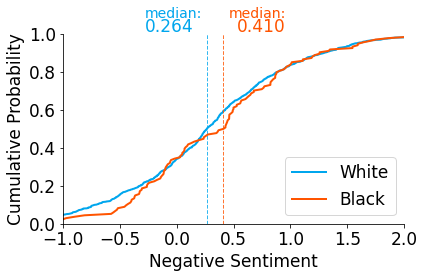

In [12]:
import pylab as pl
import numpy as np
from scipy.stats import mannwhitneyu
import random

# Mistrust scores
print(time.strftime("%Y-%m-%d %H:%M:%s"))
import pickle as pickle
with open('../data/neg_sentiment.pkl', 'rb') as f:
    scores = pickle.load(f)
vals = np.array(list(scores.values()))
mu = vals.mean()
std = vals.std()
scores = {hadm_id:old_div((s-mu),std) for hadm_id,s in list(scores.items())}
print(time.strftime("%Y-%m-%d %H:%M:%s"))

# Get b/w cohorts
white_ids = set(eol_cohort.loc[eol_cohort['race']=='White'].hadm_id.values) & set(scores.keys())
black_ids = set(eol_cohort.loc[eol_cohort['race']=='Black'].hadm_id.values) & set(scores.keys())
#white_ids = set(demographics.loc[demographics['race']=='White'].hadm_id.values) & set(scores.keys())
#black_ids = set(demographics.loc[demographics['race']=='Black'].hadm_id.values) & set(scores.keys())

white_mistrust = [scores[hadm_id] for hadm_id in white_ids]
black_mistrust = [scores[hadm_id] for hadm_id in black_ids]


def list_median(vals):
    svals = sorted(vals)
    return svals[old_div(len(svals),2)]

def captialize(t):
    return ' '.join([w.capitalize() for w in t.split()])

colors = ['#00A6ED', '#FF5400']
i = 0

fig = pl.figure()

w_median = list_median(white_mistrust) 
b_median = list_median(black_mistrust)
larger_median = max(w_median, b_median)

mistrusts = {'White':white_mistrust, 'Black':black_mistrust}

for demographic in ['White', 'Black']:
    vals = list(mistrusts[demographic])
    #print(len(vals))
    #print (np.sort(vals)[int(len(vals)/2)])
    plt.plot(np.sort(vals), np.linspace(0, 1, len(vals), endpoint=False), color=colors[i], label = demographic, lw=2)
    plt.xlim((-1,2))
    plt.ylim((0,1.0))

    median = np.sort(vals)[int(old_div(len(vals),2))]
    plt.axvline(x=median, linestyle="--", lw=1, color=colors[i], alpha=0.8) 
    p = 0.55
    if median == larger_median:
        h = 'right'
    else:
        p = -p
        h = 'left'
    #h = 'center'
    print(p)
    plt.text(x=median+p, y=1.085, horizontalalignment=h, s="median:", fontsize=14, color=colors[i])
    plt.text(x=median+p, y=1.01 , horizontalalignment=h, s=('%.3f' % median), fontsize=17, color=colors[i])

    i += 1

ax = plt.subplot(111)    
ax.spines["top"].set_visible(False)    
#ax.spines["bottom"].set_visible(False)    
ax.spines["right"].set_visible(False)    
#ax.spines["left"].set_visible(False)    
plt.yticks(fontsize=17)    
plt.xticks(fontsize=17) 

plt.legend(loc=4, fontsize=17)
plt.ylabel("Cumulative Probability", fontsize=17)
plt.xlabel("Negative Sentiment", fontsize=17)

plt.tight_layout()
plt.savefig('../images/chapter4/neg_sentiment_mimic.png')

p1 = list(white_mistrust)
p2 = list(black_mistrust)
w = mannwhitneyu(p1, p2)
print('\twhite:   ', len(p1), w_median)
print('\tblack:', len(p2), b_median)
print('\tp-value:', w.pvalue)

plt.show()

<h1>Trust-based Treatment Disparities</h1>

2025-12-04 03:41:1764819707
2025-12-04 03:41:1764819707
mistrust_noncompliant
vent
	trust:    1109 2976.0
	mistrust: 146 1440.0
	p-value: 4.223945015512071e-11


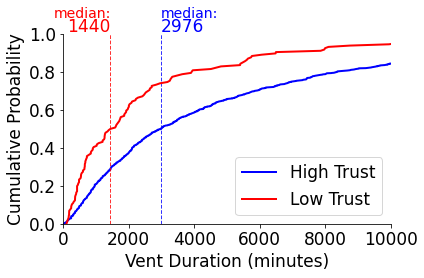

mistrust_noncompliant
vaso
	trust:    83 2730.0
	mistrust: 11 1937.0
	p-value: 0.28617567656858267


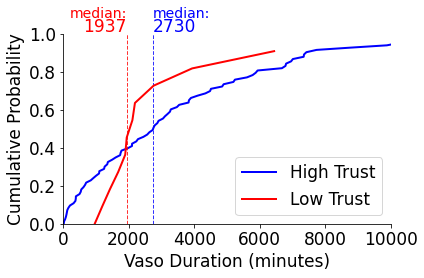

100%|██████████| 2/2 [00:00<00:00, 2610.83it/s]


vent 31 38 418 418 419
vaso 37 46 31 31 32


100%|██████████| 2/2 [00:00<00:00, 2015.52it/s]

vent
	 low
		 High Trust 366
		 Low Trust 58
	 medium
		 High Trust 378
		 Low Trust 47
	 high
		 High Trust 365
		 Low Trust 41
vaso
	 low
		 High Trust 32
		 Low Trust 3
	 medium
		 High Trust 31
		 Low Trust 2
	 high
		 High Trust 20
		 Low Trust 6
vent
	 vent low
		 High Trust 366
		 Low Trust 58
vent low
	trust:    366 2357.0
	mistrust: 58 1018.0
	p-value: 2.2022653861527214e-06
	 vent medium
		 High Trust 378
		 Low Trust 47
vent medium
	trust:    378 2655.0
	mistrust: 47 1350.0
	p-value: 0.0007670949893936439
	 vent high
		 High Trust 365
		 Low Trust 41
vent high
	trust:    365 4140.0
	mistrust: 41 2100.0
	p-value: 0.0008757457336906003


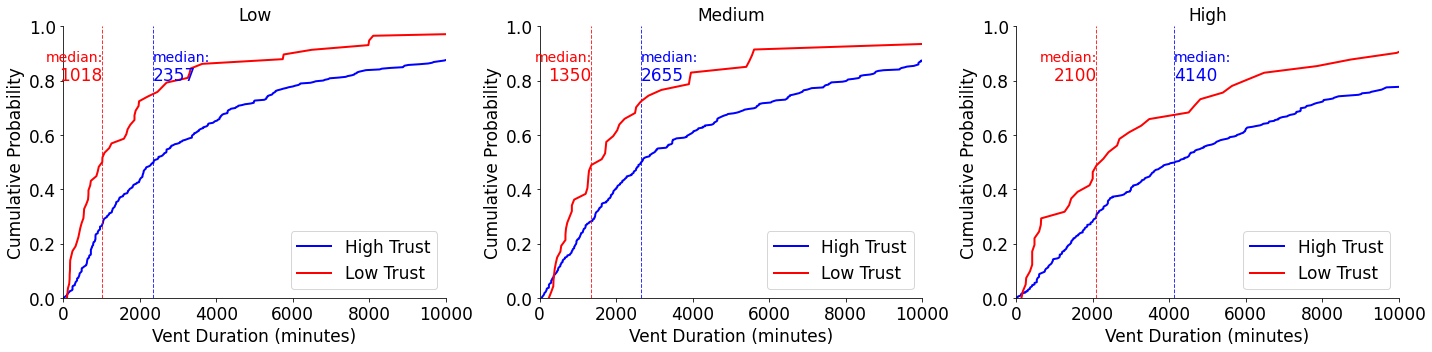

vaso
	 vaso low
		 High Trust 32
		 Low Trust 3
vaso low
	trust:    32 2097.0
	mistrust: 3 1937.0
	p-value: 0.39544116147031205
	 vaso medium
		 High Trust 31
		 Low Trust 2
vaso medium
	trust:    31 3258.0
	mistrust: 2 6440.0
	p-value: 0.48495360742976884
	 vaso high
		 High Trust 20
		 Low Trust 6
vaso high
	trust:    20 3044.0
	mistrust: 6 2110.0
	p-value: 0.15765122604087273


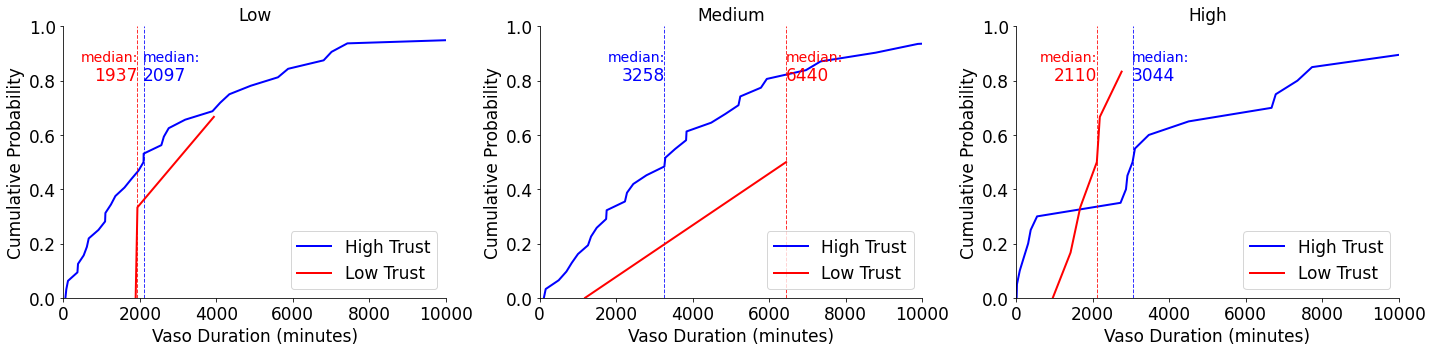

In [13]:
# Mistrust scores
print(time.strftime("%Y-%m-%d %H:%M:%s"))
import pickle as pickle

mistrust_str = 'mistrust_noncompliant'
#mistrust_str = 'mistrust_autopsy'
#mistrust_str = 'neg_sentiment'

with open('../data/%s.pkl' % mistrust_str, 'rb') as f:
    trust_scores = pickle.load(f)
print(time.strftime("%Y-%m-%d %H:%M:%s"))


%matplotlib inline

import pylab as pl
import numpy as np
from scipy.stats import mannwhitneyu


# Put each treatment into the dictionary
T = {}
for vaso,vaso_quantity in list(vaso_quantities.items()): 
    # Get size of b/w cohorts
    vaso_white_ids = set(eol_cohort.loc[eol_cohort['race']=='White'].hadm_id.values) & set(trust_scores.keys()) & set(vaso_quantity.keys())
    vaso_black_ids = set(eol_cohort.loc[eol_cohort['race']=='Black'].hadm_id.values) & set(trust_scores.keys()) & set(vaso_quantity.keys())

    # Stratify into high/low trust
    vaso_cohort = (vaso_white_ids | vaso_black_ids)  & set(vaso_quantity.keys())
    vaso_cohort_ids = sorted([(hadm_id,trust_scores[hadm_id]) for hadm_id in vaso_cohort], key=lambda t:t[1])
    vaso_trust_ids    = [hadm_id for hadm_id,score in vaso_cohort_ids[:len(vaso_white_ids) ]]
    vaso_mistrust_ids = [hadm_id for hadm_id,score in vaso_cohort_ids[ len(vaso_white_ids):]]

    trust_eol_vaso    = {hadm_id:vaso_quantity[hadm_id] for hadm_id in vaso_trust_ids    if hadm_id in vaso_quantity}
    mistrust_eol_vaso = {hadm_id:vaso_quantity[hadm_id] for hadm_id in vaso_mistrust_ids if hadm_id in vaso_quantity}
    T[vaso] = {'Low Trust':mistrust_eol_vaso, 'High Trust':trust_eol_vaso}

# Get size of b/w cohorts
vent_white_ids = set(eol_cohort.loc[eol_cohort['race']=='White'].hadm_id.values) & set(trust_scores.keys()) & set(vent_quantity.keys())
vent_black_ids = set(eol_cohort.loc[eol_cohort['race']=='Black'].hadm_id.values) & set(trust_scores.keys()) & set(vent_quantity.keys())

# Stratify into high/low trust
vent_cohort = (vent_white_ids | vent_black_ids)
vent_cohort_ids = sorted([(hadm_id,trust_scores[hadm_id]) for hadm_id in vent_cohort], key=lambda t:t[1])
vent_trust_ids    = [hadm_id for hadm_id,score in vent_cohort_ids[:len(vent_white_ids) ]]
vent_mistrust_ids = [hadm_id for hadm_id,score in vent_cohort_ids[ len(vent_white_ids):]]

trust_eol_vent    = {hadm_id:vent_quantity[hadm_id] for hadm_id in vent_trust_ids   }
mistrust_eol_vent = {hadm_id:vent_quantity[hadm_id] for hadm_id in vent_mistrust_ids}
T['vent'] =  {'Low Trust':mistrust_eol_vent, 'High Trust':trust_eol_vent}



import pylab as plt

def list_median(vals):
    svals = sorted(vals)
    return svals[old_div(len(svals),2)]

def captialize(t):
    return ' '.join([w.capitalize() for w in t.split()])

colors = ['#0000FF', '#FF0000']
for treatment in sorted(T.keys(), reverse=True):
    i = 0
    
    fig = pl.figure(treatment)

    t_median = list_median(list(T[treatment]['High Trust'].values()))
    m_median = list_median(list(T[treatment][ 'Low Trust'].values()))
    larger_median = min(t_median, m_median)
        
    for demographic in ['High Trust', 'Low Trust']:
        vals = list(T[treatment][demographic].values())
        #print(len(vals))
        #print (np.sort(vals)[int(len(vals)/2)])
        plt.plot(np.sort(vals), np.linspace(0, 1, len(vals), endpoint=False), color=colors[i], label = demographic, lw=2)
        plt.xlim((0,10000))
        plt.ylim((0,1.0))

        median = np.sort(vals)[int(old_div(len(vals),2))]
        plt.axvline(x=median, linestyle="--", lw=1, color=colors[i], alpha=0.8) 
        if median == larger_median:
            p = 10
            h = 'right'
        else:
            p = -10
            h = 'left'
        #h = 'center'
        plt.text(x=median+p, y=1.085, horizontalalignment=h, s="median:", fontsize=14, color=colors[i])
        plt.text(x=median+p, y=1.01 , horizontalalignment=h, s=str(int(median)), fontsize=17, color=colors[i])

        i += 1

    ax = plt.subplot(111)    
    ax.spines["top"].set_visible(False)    
    #ax.spines["bottom"].set_visible(False)    
    ax.spines["right"].set_visible(False)    
    #ax.spines["left"].set_visible(False)    
    plt.yticks(fontsize=17)    
    plt.xticks(fontsize=17) 

    plt.legend(loc=4, fontsize=17)
    plt.ylabel("Cumulative Probability", fontsize=17)
    plt.xlabel("%s Duration (minutes)" % captialize(treatment), fontsize=17)

    plt.tight_layout()
    plt.savefig('../images/chapter5/%s_mimic_%s.png' % (mistrust_str,treatment))

    p1 = list(T[treatment]['High Trust'].values())
    p2 = list(T[treatment][ 'Low Trust'].values())
    w = mannwhitneyu(p1, p2)
    print(mistrust_str)
    print(treatment)
    print('\ttrust:   ', len(p1), t_median)
    print('\tmistrust:', len(p2), m_median)
    print('\tp-value:', w.pvalue)
    
    plt.show()
    
    
    
treatment_severity_populations = {treatment:[] for treatment in sorted(T.keys(), reverse=True)}
for treatment,race_cohorts in tqdm.tqdm(sorted(T.items(), reverse=True)):
    for race,race_cohort in list(race_cohorts.items()):
        for hadm_id,amount in list(race_cohort.items()):
            severity = severities[hadm_id]
            treatment_severity_populations[treatment].append(severity)

treatment_severity_thresholds = {}
for treatment,scores in sorted(treatment_severity_populations.items(), reverse=True):
    vals = sorted(scores)
    n = len(vals)
    print(treatment, vals[old_div(n,3)], vals[old_div(2*n,3)], len(vals[:old_div(n,3)]), len(vals[old_div(n,3):old_div(2*n,3)]), len(vals[old_div(2*n,3):]))
    treatment_severity_thresholds[treatment] = vals[old_div(n,3)], vals[old_div(2*n,3)]
    
    
    
    
import tqdm

# partition by treatment
T_risk = defaultdict(lambda:defaultdict(lambda:defaultdict(list)))
for treatment,race_cohorts in tqdm.tqdm(sorted(T.items(), reverse=True)):
    for race,race_cohort in list(race_cohorts.items()):
        for hadm_id,amount in list(race_cohort.items()):
            # acuity bin
            severity = severities[hadm_id]
            if severities[hadm_id] <= treatment_severity_thresholds[treatment][0]:
                acuity = 'low'
            elif severities[hadm_id] <= treatment_severity_thresholds[treatment][1]:
                acuity = 'medium'
            else:
                acuity = 'high'

            T_risk[treatment][acuity][race].append(amount)

for treatment,cohorts in sorted(T_risk.items(), reverse=True):
    print(treatment)
    for severity in ['low', 'medium', 'high']:
        print('\t', severity)
        cohort = cohorts[severity]
        for race,ids in sorted(cohort.items()):
            print('\t\t', race, len(ids))
            
            

for treatment in sorted(T_risk.keys(), reverse=True):
    #if 'vaso' not in treatment: continue
    print(treatment)
    fig = pl.figure(treatment, (20,5))

    for i,severity in enumerate(['low','medium','high']):
        #fig = pl.figure('-'.join([treatment,severity]))
        ind = 131 + i
        ax = fig.add_subplot(ind)
                
        print('\t', treatment, severity)

        t_median = list_median(T_risk[treatment][severity]['High Trust'])
        m_median = list_median(T_risk[treatment][severity][ 'Low Trust'])
        larger_median = min(t_median, m_median)
        
        for j,demographic in enumerate(['High Trust', 'Low Trust']):
            vals = list(T_risk[treatment][severity][demographic])
            #print(len(vals))
            #print (np.sort(vals)[int(len(vals)/2)])
            ax.plot(np.sort(vals), np.linspace(0, 1, len(vals), endpoint=False), color=colors[j], label = demographic, lw=2)
            pl.xlim((0,10000))
            pl.ylim((0,1.0))

            print('\t\t', demographic, len(vals))
            median = np.sort(vals)[int(old_div(len(vals),2))]
            ax.axvline(x=median, linestyle="--", lw=1, color=colors[j], alpha=0.8) 
            if median == larger_median:
                p = 10
                h = 'right'
            else:
                p = -10
                h = 'left'
            #h = 'center'
            ax.text(x=median+p, y=0.87, horizontalalignment=h, s="median:", fontsize=14, color=colors[j])
            ax.text(x=median+p, y=0.8 , horizontalalignment=h, s=str(int(median)), fontsize=17, color=colors[j])

        #ax = pl.subplot(111)    
        ax.spines["top"].set_visible(False)    
        #ax.spines["bottom"].set_visible(False)    
        ax.spines["right"].set_visible(False)    
        #ax.spines["left"].set_visible(False)    
        pl.yticks(fontsize=17)    
        pl.xticks(fontsize=17) 

        pl.title(captialize(severity), fontsize=17)
        pl.legend(loc=4, fontsize=17)
        pl.ylabel("Cumulative Probability", fontsize=17)
        pl.xlabel("%s Duration (minutes)" % captialize(treatment), fontsize=17)

        pl.tight_layout()

        p1 = list(T_risk[treatment][severity]['High Trust'])
        p2 = list(T_risk[treatment][severity][ 'Low Trust'])
        w = mannwhitneyu(p1, p2)
        print(treatment, severity)
        print('\ttrust:   ', len(p1), t_median)
        print('\tmistrust:', len(p2), m_median)
        print('\tp-value:', w.pvalue)
    pl.savefig('../images/chapter5/%s_mimic_%s_severity.png' % (mistrust_str,treatment))
    pl.show()
    #break
    #exit()

2025-12-04 03:41:1764819708
2025-12-04 03:41:1764819708
mistrust_autopsy
vent
	trust:    1109 2908.0
	mistrust: 146 1473.0
	p-value: 2.136255208533446e-08


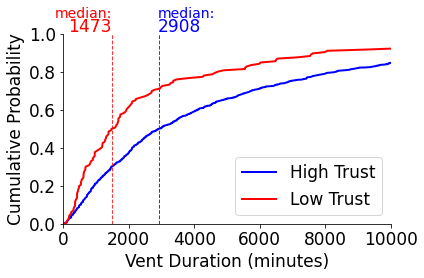

mistrust_autopsy
vaso
	trust:    83 2755.0
	mistrust: 11 1361.0
	p-value: 0.01350689780616053


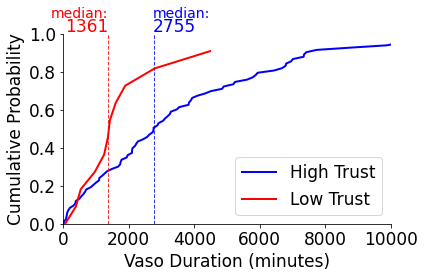

100%|██████████| 2/2 [00:00<00:00, 3407.23it/s]


vent 31 38 418 418 419
vaso 37 46 31 31 32


100%|██████████| 2/2 [00:00<00:00, 2842.63it/s]

vent
	 low
		 High Trust 362
		 Low Trust 62
	 medium
		 High Trust 379
		 Low Trust 46
	 high
		 High Trust 368
		 Low Trust 38
vaso
	 low
		 High Trust 28
		 Low Trust 7
	 medium
		 High Trust 31
		 Low Trust 2
	 high
		 High Trust 24
		 Low Trust 2
vent
	 vent low
		 High Trust 362
		 Low Trust 62
vent low
	trust:    362 2362.0
	mistrust: 62 1185.0
	p-value: 3.023748017145901e-05
	 vent medium
		 High Trust 379
		 Low Trust 46
vent medium
	trust:    379 2621.0
	mistrust: 46 1465.0
	p-value: 0.0010917871670738698
	 vent high
		 High Trust 368
		 Low Trust 38
vent high
	trust:    368 4028.0
	mistrust: 38 2107.0
	p-value: 0.042065355924159935


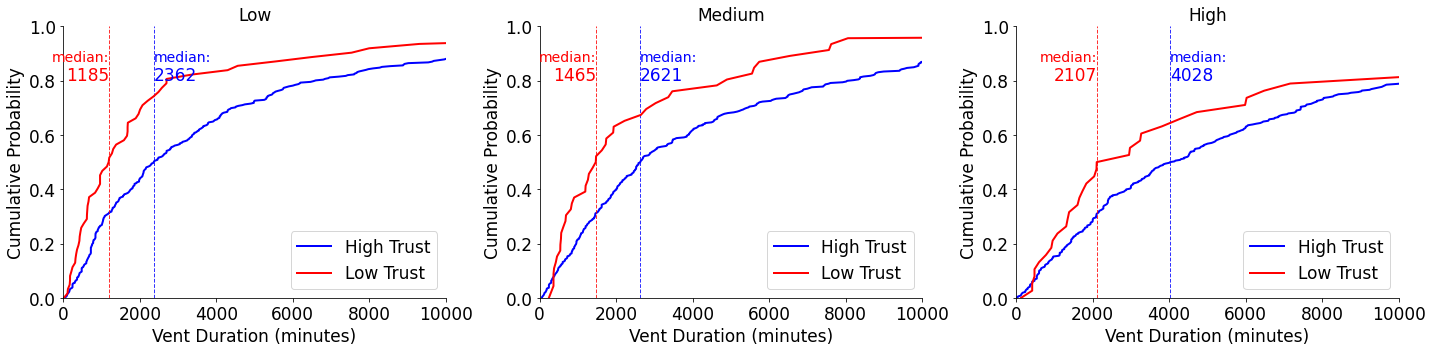

vaso
	 vaso low
		 High Trust 28
		 Low Trust 7
vaso low
	trust:    28 2628.0
	mistrust: 7 1245.0
	p-value: 0.007921783083001071
	 vaso medium
		 High Trust 31
		 Low Trust 2
vaso medium
	trust:    31 3258.0
	mistrust: 2 4482.0
	p-value: 0.39586198304950226
	 vaso high
		 High Trust 24
		 Low Trust 2
vaso high
	trust:    24 2872.0
	mistrust: 2 1423.0
	p-value: 0.18032218807446937


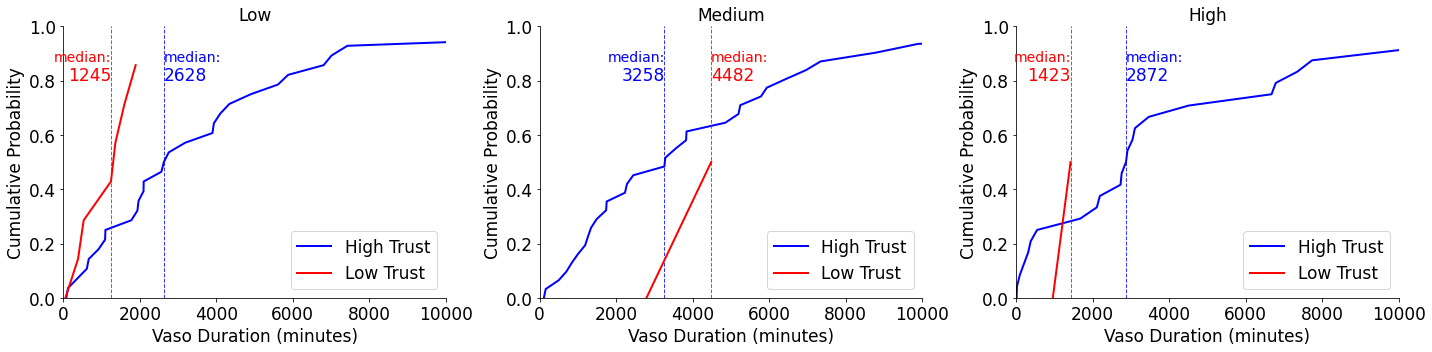

In [14]:
# Mistrust scores
print(time.strftime("%Y-%m-%d %H:%M:%s"))
import pickle as pickle

#mistrust_str = 'mistrust_noncompliant'
mistrust_str = 'mistrust_autopsy'
#mistrust_str = 'neg_sentiment'

with open('../data/%s.pkl' % mistrust_str, 'rb') as f:
    trust_scores = pickle.load(f)
print(time.strftime("%Y-%m-%d %H:%M:%s"))


%matplotlib inline

import pylab as pl
import numpy as np
from scipy.stats import mannwhitneyu


# Put each treatment into the dictionary
T = {}
for vaso,vaso_quantity in list(vaso_quantities.items()): 
    # Get size of b/w cohorts
    vaso_white_ids = set(eol_cohort.loc[eol_cohort['race']=='White'].hadm_id.values) & set(trust_scores.keys()) & set(vaso_quantity.keys())
    vaso_black_ids = set(eol_cohort.loc[eol_cohort['race']=='Black'].hadm_id.values) & set(trust_scores.keys()) & set(vaso_quantity.keys())

    # Stratify into high/low trust
    vaso_cohort = (vaso_white_ids | vaso_black_ids)  & set(vaso_quantity.keys())
    vaso_cohort_ids = sorted([(hadm_id,trust_scores[hadm_id]) for hadm_id in vaso_cohort], key=lambda t:t[1])
    vaso_trust_ids    = [hadm_id for hadm_id,score in vaso_cohort_ids[:len(vaso_white_ids) ]]
    vaso_mistrust_ids = [hadm_id for hadm_id,score in vaso_cohort_ids[ len(vaso_white_ids):]]

    trust_eol_vaso    = {hadm_id:vaso_quantity[hadm_id] for hadm_id in vaso_trust_ids    if hadm_id in vaso_quantity}
    mistrust_eol_vaso = {hadm_id:vaso_quantity[hadm_id] for hadm_id in vaso_mistrust_ids if hadm_id in vaso_quantity}
    T[vaso] = {'Low Trust':mistrust_eol_vaso, 'High Trust':trust_eol_vaso}

# Get size of b/w cohorts
vent_white_ids = set(eol_cohort.loc[eol_cohort['race']=='White'].hadm_id.values) & set(trust_scores.keys()) & set(vent_quantity.keys())
vent_black_ids = set(eol_cohort.loc[eol_cohort['race']=='Black'].hadm_id.values) & set(trust_scores.keys()) & set(vent_quantity.keys())

# Stratify into high/low trust
vent_cohort = (vent_white_ids | vent_black_ids)
vent_cohort_ids = sorted([(hadm_id,trust_scores[hadm_id]) for hadm_id in vent_cohort], key=lambda t:t[1])
vent_trust_ids    = [hadm_id for hadm_id,score in vent_cohort_ids[:len(vent_white_ids) ]]
vent_mistrust_ids = [hadm_id for hadm_id,score in vent_cohort_ids[ len(vent_white_ids):]]

trust_eol_vent    = {hadm_id:vent_quantity[hadm_id] for hadm_id in vent_trust_ids   }
mistrust_eol_vent = {hadm_id:vent_quantity[hadm_id] for hadm_id in vent_mistrust_ids}
T['vent'] =  {'Low Trust':mistrust_eol_vent, 'High Trust':trust_eol_vent}



import pylab as plt

def list_median(vals):
    svals = sorted(vals)
    return svals[old_div(len(svals),2)]

def captialize(t):
    return ' '.join([w.capitalize() for w in t.split()])

colors = ['#0000FF', '#FF0000']
for treatment in sorted(T.keys(), reverse=True):
    i = 0
    
    fig = pl.figure(treatment)

    t_median = list_median(list(T[treatment]['High Trust'].values()))
    m_median = list_median(list(T[treatment][ 'Low Trust'].values()))
    larger_median = min(t_median, m_median)
        
    for demographic in ['High Trust', 'Low Trust']:
        vals = list(T[treatment][demographic].values())
        #print(len(vals))
        #print (np.sort(vals)[int(len(vals)/2)])
        plt.plot(np.sort(vals), np.linspace(0, 1, len(vals), endpoint=False), color=colors[i], label = demographic, lw=2)
        plt.xlim((0,10000))
        plt.ylim((0,1.0))

        median = np.sort(vals)[int(old_div(len(vals),2))]
        plt.axvline(x=median, linestyle="--", lw=1, color=colors[i], alpha=0.8) 
        if median == larger_median:
            p = 10
            h = 'right'
        else:
            p = -10
            h = 'left'
        #h = 'center'
        plt.text(x=median+p, y=1.085, horizontalalignment=h, s="median:", fontsize=14, color=colors[i])
        plt.text(x=median+p, y=1.01 , horizontalalignment=h, s=str(int(median)), fontsize=17, color=colors[i])

        i += 1

    ax = plt.subplot(111)    
    ax.spines["top"].set_visible(False)    
    #ax.spines["bottom"].set_visible(False)    
    ax.spines["right"].set_visible(False)    
    #ax.spines["left"].set_visible(False)    
    plt.yticks(fontsize=17)    
    plt.xticks(fontsize=17) 

    plt.legend(loc=4, fontsize=17)
    plt.ylabel("Cumulative Probability", fontsize=17)
    plt.xlabel("%s Duration (minutes)" % captialize(treatment), fontsize=17)

    plt.tight_layout()
    plt.savefig('../images/chapter5/%s_mimic_%s.png' % (mistrust_str,treatment))

    p1 = list(T[treatment]['High Trust'].values())
    p2 = list(T[treatment][ 'Low Trust'].values())
    w = mannwhitneyu(p1, p2)
    print(mistrust_str)
    print(treatment)
    print('\ttrust:   ', len(p1), t_median)
    print('\tmistrust:', len(p2), m_median)
    print('\tp-value:', w.pvalue)
    
    plt.show()
    
    
    
treatment_severity_populations = {treatment:[] for treatment in sorted(T.keys(), reverse=True)}
for treatment,race_cohorts in tqdm.tqdm(sorted(T.items(), reverse=True)):
    for race,race_cohort in list(race_cohorts.items()):
        for hadm_id,amount in list(race_cohort.items()):
            severity = severities[hadm_id]
            treatment_severity_populations[treatment].append(severity)

treatment_severity_thresholds = {}
for treatment,scores in sorted(treatment_severity_populations.items(), reverse=True):
    vals = sorted(scores)
    n = len(vals)
    print(treatment, vals[old_div(n,3)], vals[old_div(2*n,3)], len(vals[:old_div(n,3)]), len(vals[old_div(n,3):old_div(2*n,3)]), len(vals[old_div(2*n,3):]))
    treatment_severity_thresholds[treatment] = vals[old_div(n,3)], vals[old_div(2*n,3)]
    
    
    
    
import tqdm

# partition by treatment
T_risk = defaultdict(lambda:defaultdict(lambda:defaultdict(list)))
for treatment,race_cohorts in tqdm.tqdm(sorted(T.items(), reverse=True)):
    for race,race_cohort in list(race_cohorts.items()):
        for hadm_id,amount in list(race_cohort.items()):
            # acuity bin
            severity = severities[hadm_id]
            if severities[hadm_id] <= treatment_severity_thresholds[treatment][0]:
                acuity = 'low'
            elif severities[hadm_id] <= treatment_severity_thresholds[treatment][1]:
                acuity = 'medium'
            else:
                acuity = 'high'

            T_risk[treatment][acuity][race].append(amount)

for treatment,cohorts in sorted(T_risk.items(), reverse=True):
    print(treatment)
    for severity in ['low', 'medium', 'high']:
        print('\t', severity)
        cohort = cohorts[severity]
        for race,ids in sorted(cohort.items()):
            print('\t\t', race, len(ids))
            
            

for treatment in sorted(T_risk.keys(), reverse=True):
    #if 'vaso' not in treatment: continue
    print(treatment)
    fig = pl.figure(treatment, (20,5))

    for i,severity in enumerate(['low','medium','high']):
        #fig = pl.figure('-'.join([treatment,severity]))
        ind = 131 + i
        ax = fig.add_subplot(ind)
                
        print('\t', treatment, severity)

        t_median = list_median(T_risk[treatment][severity]['High Trust'])
        m_median = list_median(T_risk[treatment][severity][ 'Low Trust'])
        larger_median = min(t_median, m_median)
        
        for j,demographic in enumerate(['High Trust', 'Low Trust']):
            vals = list(T_risk[treatment][severity][demographic])
            #print(len(vals))
            #print (np.sort(vals)[int(len(vals)/2)])
            ax.plot(np.sort(vals), np.linspace(0, 1, len(vals), endpoint=False), color=colors[j], label = demographic, lw=2)
            pl.xlim((0,10000))
            pl.ylim((0,1.0))

            print('\t\t', demographic, len(vals))
            median = np.sort(vals)[int(old_div(len(vals),2))]
            ax.axvline(x=median, linestyle="--", lw=1, color=colors[j], alpha=0.8) 
            if median == larger_median:
                p = 10
                h = 'right'
            else:
                p = -10
                h = 'left'
            #h = 'center'
            ax.text(x=median+p, y=0.87, horizontalalignment=h, s="median:", fontsize=14, color=colors[j])
            ax.text(x=median+p, y=0.8 , horizontalalignment=h, s=str(int(median)), fontsize=17, color=colors[j])

        #ax = pl.subplot(111)    
        ax.spines["top"].set_visible(False)    
        #ax.spines["bottom"].set_visible(False)    
        ax.spines["right"].set_visible(False)    
        #ax.spines["left"].set_visible(False)    
        pl.yticks(fontsize=17)    
        pl.xticks(fontsize=17) 

        pl.title(captialize(severity), fontsize=17)
        pl.legend(loc=4, fontsize=17)
        pl.ylabel("Cumulative Probability", fontsize=17)
        pl.xlabel("%s Duration (minutes)" % captialize(treatment), fontsize=17)

        pl.tight_layout()

        p1 = list(T_risk[treatment][severity]['High Trust'])
        p2 = list(T_risk[treatment][severity][ 'Low Trust'])
        w = mannwhitneyu(p1, p2)
        print(treatment, severity)
        print('\ttrust:   ', len(p1), t_median)
        print('\tmistrust:', len(p2), m_median)
        print('\tp-value:', w.pvalue)
    pl.savefig('../images/chapter5/%s_mimic_%s_severity.png' % (mistrust_str,treatment))
    pl.show()
    #break
    #exit()

2025-12-04 03:41:1764819709
2025-12-04 03:41:1764819709
neg_sentiment
vent
	trust:    706 2633.0
	mistrust: 90 2700.0
	p-value: 0.21008666479917598


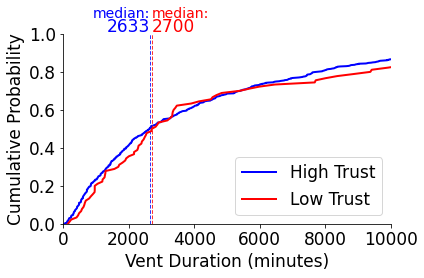

neg_sentiment
vaso
	trust:    49 2110.0
	mistrust: 6 4852.0
	p-value: 0.1689280490727788


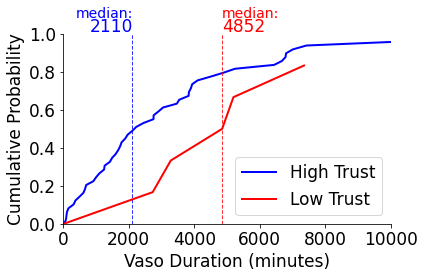

100%|██████████| 2/2 [00:00<00:00, 3858.61it/s]


vent 31 38 265 265 266
vaso 37 46 18 18 19


100%|██████████| 2/2 [00:00<00:00, 4132.32it/s]

vent
	 low
		 High Trust 257
		 Low Trust 29
	 medium
		 High Trust 247
		 Low Trust 32
	 high
		 High Trust 202
		 Low Trust 29
vaso
	 low
		 High Trust 20
	 medium
		 High Trust 15
		 Low Trust 3
	 high
		 High Trust 14
		 Low Trust 3
vent
	 vent low
		 High Trust 257
		 Low Trust 29
vent low
	trust:    257 2130.0
	mistrust: 29 2298.0
	p-value: 0.4013380659707287
	 vent medium
		 High Trust 247
		 Low Trust 32
vent medium
	trust:    247 2520.0
	mistrust: 32 2400.0
	p-value: 0.3316200176109831
	 vent high
		 High Trust 202
		 Low Trust 29
vent high
	trust:    202 3540.0
	mistrust: 29 4560.0
	p-value: 0.08015418789433376


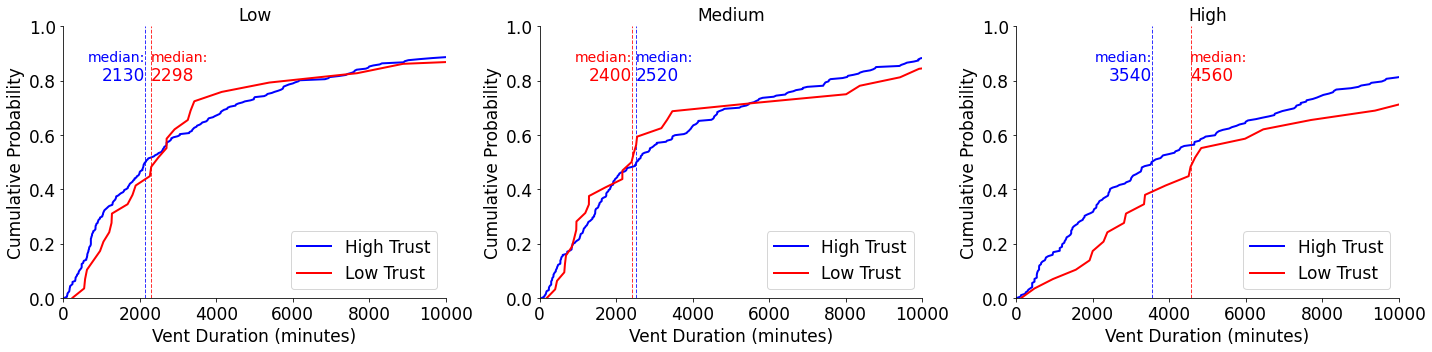

vaso
Skipping vaso low due to empty cohort
	 vaso medium
		 High Trust 15
		 Low Trust 3
vaso medium
	trust:    15 1736.0
	mistrust: 3 4852.0
	p-value: 0.06176712687628474
	 vaso high
		 High Trust 14
		 Low Trust 3
vaso high
	trust:    14 2909.0
	mistrust: 3 2730.0
	p-value: 0.42505336956926293


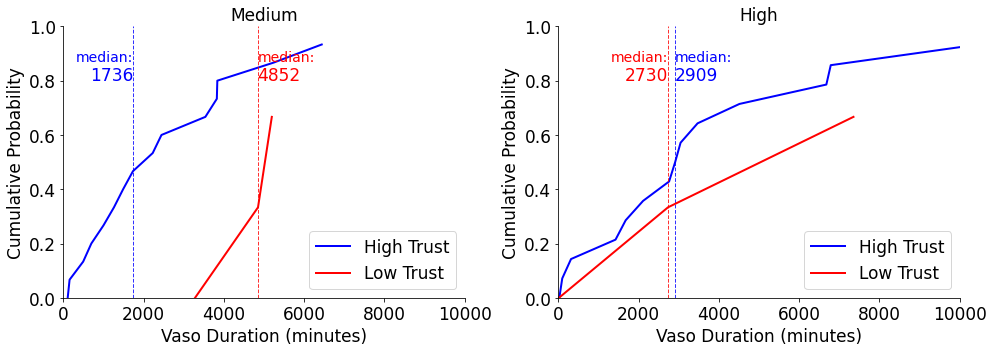

In [15]:
# Mistrust scores
print(time.strftime("%Y-%m-%d %H:%M:%s"))
import pickle as pickle

#mistrust_str = 'mistrust_noncompliant'
#mistrust_str = 'mistrust_autopsy'
mistrust_str = 'neg_sentiment'

with open('../data/%s.pkl' % mistrust_str, 'rb') as f:
    trust_scores = pickle.load(f)
print(time.strftime("%Y-%m-%d %H:%M:%s"))


%matplotlib inline

import pylab as pl
import numpy as np
from scipy.stats import mannwhitneyu


# Put each treatment into the dictionary
T = {}
for vaso,vaso_quantity in sorted(vaso_quantities.items(), reverse=True): 
    # Get size of b/w cohorts
    vaso_white_ids = set(eol_cohort.loc[eol_cohort['race']=='White'].hadm_id.values) & set(trust_scores.keys()) & set(vaso_quantity.keys())
    vaso_black_ids = set(eol_cohort.loc[eol_cohort['race']=='Black'].hadm_id.values) & set(trust_scores.keys()) & set(vaso_quantity.keys())

    # Stratify into high/low trust
    vaso_cohort = (vaso_white_ids | vaso_black_ids)  & set(vaso_quantity.keys())
    vaso_cohort_ids = sorted([(hadm_id,trust_scores[hadm_id]) for hadm_id in vaso_cohort], key=lambda t:t[1])
    vaso_trust_ids    = [hadm_id for hadm_id,score in vaso_cohort_ids[:len(vaso_white_ids) ]]
    vaso_mistrust_ids = [hadm_id for hadm_id,score in vaso_cohort_ids[ len(vaso_white_ids):]]

    trust_eol_vaso    = {hadm_id:vaso_quantity[hadm_id] for hadm_id in vaso_trust_ids    if hadm_id in vaso_quantity}
    mistrust_eol_vaso = {hadm_id:vaso_quantity[hadm_id] for hadm_id in vaso_mistrust_ids if hadm_id in vaso_quantity}
    T[vaso] = {'Low Trust':mistrust_eol_vaso, 'High Trust':trust_eol_vaso}

# Get size of b/w cohorts
vent_white_ids = set(eol_cohort.loc[eol_cohort['race']=='White'].hadm_id.values) & set(trust_scores.keys()) & set(vent_quantity.keys())
vent_black_ids = set(eol_cohort.loc[eol_cohort['race']=='Black'].hadm_id.values) & set(trust_scores.keys()) & set(vent_quantity.keys())

# Stratify into high/low trust
vent_cohort = (vent_white_ids | vent_black_ids)
vent_cohort_ids = sorted([(hadm_id,trust_scores[hadm_id]) for hadm_id in vent_cohort], key=lambda t:t[1])
vent_trust_ids    = [hadm_id for hadm_id,score in vent_cohort_ids[:len(vent_white_ids) ]]
vent_mistrust_ids = [hadm_id for hadm_id,score in vent_cohort_ids[ len(vent_white_ids):]]

trust_eol_vent    = {hadm_id:vent_quantity[hadm_id] for hadm_id in vent_trust_ids   }
mistrust_eol_vent = {hadm_id:vent_quantity[hadm_id] for hadm_id in vent_mistrust_ids}
T['vent'] =  {'Low Trust':mistrust_eol_vent, 'High Trust':trust_eol_vent}



import pylab as plt

def list_median(vals):
    if not vals: 
        raise ValueError("Empty list has no median")
    svals = sorted(vals)
    return svals[old_div(len(svals),2)]

def captialize(t):
    return ' '.join([w.capitalize() for w in t.split()])

colors = ['#0000FF', '#FF0000']
for treatment in sorted(T.keys(), reverse=True):
    i = 0
    
    fig = pl.figure(treatment)

    t_median = list_median(list(T[treatment]['High Trust'].values()))
    m_median = list_median(list(T[treatment][ 'Low Trust'].values()))
    larger_median = min(t_median, m_median)
        
    for demographic in ['High Trust', 'Low Trust']:
        vals = list(T[treatment][demographic].values())
        #print(len(vals))
        #print (np.sort(vals)[int(len(vals)/2)])
        plt.plot(np.sort(vals), np.linspace(0, 1, len(vals), endpoint=False), color=colors[i], label = demographic, lw=2)
        plt.xlim((0,10000))
        plt.ylim((0,1.0))

        median = np.sort(vals)[int(old_div(len(vals),2))]
        plt.axvline(x=median, linestyle="--", lw=1, color=colors[i], alpha=0.8) 
        if median == larger_median:
            p = 10
            h = 'right'
        else:
            p = -10
            h = 'left'
        #h = 'center'
        plt.text(x=median+p, y=1.085, horizontalalignment=h, s="median:", fontsize=14, color=colors[i])
        plt.text(x=median+p, y=1.01 , horizontalalignment=h, s=str(int(median)), fontsize=17, color=colors[i])

        i += 1

    ax = plt.subplot(111)    
    ax.spines["top"].set_visible(False)    
    #ax.spines["bottom"].set_visible(False)    
    ax.spines["right"].set_visible(False)    
    #ax.spines["left"].set_visible(False)    
    plt.yticks(fontsize=17)    
    plt.xticks(fontsize=17) 

    plt.legend(loc=4, fontsize=17)
    plt.ylabel("Cumulative Probability", fontsize=17)
    plt.xlabel("%s Duration (minutes)" % captialize(treatment), fontsize=17)

    plt.tight_layout()
    plt.savefig('../images/chapter5/%s_mimic_%s.png' % (mistrust_str,treatment))

    p1 = list(T[treatment]['High Trust'].values())
    p2 = list(T[treatment][ 'Low Trust'].values())
    w = mannwhitneyu(p1, p2)
    print(mistrust_str)
    print(treatment)
    print('\ttrust:   ', len(p1), t_median)
    print('\tmistrust:', len(p2), m_median)
    print('\tp-value:', w.pvalue)
    
    plt.show()
    
    
    
treatment_severity_populations = {treatment:[] for treatment in list(T.keys())}
for treatment,race_cohorts in tqdm.tqdm(sorted(T.items(), reverse=True)):
    for race,race_cohort in list(race_cohorts.items()):
        for hadm_id,amount in list(race_cohort.items()):
            severity = severities[hadm_id]
            treatment_severity_populations[treatment].append(severity)

treatment_severity_thresholds = {}
for treatment,scores in sorted(treatment_severity_populations.items(), reverse=True):
    vals = sorted(scores)
    n = len(vals)
    print(treatment, vals[old_div(n,3)], vals[old_div(2*n,3)], len(vals[:old_div(n,3)]), len(vals[old_div(n,3):old_div(2*n,3)]), len(vals[old_div(2*n,3):]))
    treatment_severity_thresholds[treatment] = vals[old_div(n,3)], vals[old_div(2*n,3)]
    
    
    
    
import tqdm

# partition by treatment
T_risk = defaultdict(lambda:defaultdict(lambda:defaultdict(list)))
for treatment,race_cohorts in tqdm.tqdm(sorted(T.items(), reverse=True)):
    for race,race_cohort in list(race_cohorts.items()):
        for hadm_id,amount in list(race_cohort.items()):
            # acuity bin
            severity = severities[hadm_id]
            if severities[hadm_id] <= treatment_severity_thresholds[treatment][0]:
                acuity = 'low'
            elif severities[hadm_id] <= treatment_severity_thresholds[treatment][1]:
                acuity = 'medium'
            else:
                acuity = 'high'

            T_risk[treatment][acuity][race].append(amount)

for treatment,cohorts in sorted(T_risk.items(), reverse=True):
    print(treatment)
    for severity in ['low', 'medium', 'high']:
        print('\t', severity)
        cohort = cohorts[severity]
        for race,ids in sorted(cohort.items()):
            print('\t\t', race, len(ids))
            
            

for treatment in sorted(T_risk.keys(), reverse=True):
    #if 'vaso' not in treatment: continue
    print(treatment)
    fig = pl.figure(treatment, (20,5))

    for i,severity in enumerate(['low','medium','high']):
        p1 = list(T_risk[treatment][severity]['High Trust'])
        p2 = list(T_risk[treatment][severity][ 'Low Trust'])
        if not p1 or not p2:
            print("Skipping %s %s due to empty cohort" % (treatment, severity))
            continue
        #fig = pl.figure('-'.join([treatment,severity]))
        ind = 131 + i
        ax = fig.add_subplot(ind)
                
        print('\t', treatment, severity)

        t_median = list_median(p1)
        m_median = list_median(p2)
        larger_median = min(t_median, m_median)
        
        for j,demographic in enumerate(['High Trust', 'Low Trust']):
            vals = list(T_risk[treatment][severity][demographic])
            #print(len(vals))
            #print (np.sort(vals)[int(len(vals)/2)])
            ax.plot(np.sort(vals), np.linspace(0, 1, len(vals), endpoint=False), color=colors[j], label = demographic, lw=2)
            pl.xlim((0,10000))
            pl.ylim((0,1.0))

            print('\t\t', demographic, len(vals))
            median = np.sort(vals)[int(old_div(len(vals),2))]
            ax.axvline(x=median, linestyle="--", lw=1, color=colors[j], alpha=0.8) 
            if median == larger_median:
                p = 10
                h = 'right'
            else:
                p = -10
                h = 'left'
            #h = 'center'
            ax.text(x=median+p, y=0.87, horizontalalignment=h, s="median:", fontsize=14, color=colors[j])
            ax.text(x=median+p, y=0.8 , horizontalalignment=h, s=str(int(median)), fontsize=17, color=colors[j])

        #ax = pl.subplot(111)    
        ax.spines["top"].set_visible(False)    
        #ax.spines["bottom"].set_visible(False)    
        ax.spines["right"].set_visible(False)    
        #ax.spines["left"].set_visible(False)    
        pl.yticks(fontsize=17)    
        pl.xticks(fontsize=17) 

        pl.title(captialize(severity), fontsize=17)
        pl.legend(loc=4, fontsize=17)
        pl.ylabel("Cumulative Probability", fontsize=17)
        pl.xlabel("%s Duration (minutes)" % captialize(treatment), fontsize=17)

        pl.tight_layout()

        p1 = list(T_risk[treatment][severity]['High Trust'])
        p2 = list(T_risk[treatment][severity][ 'Low Trust'])
        w = mannwhitneyu(p1, p2)
        print(treatment, severity)
        print('\ttrust:   ', len(p1), t_median)
        print('\tmistrust:', len(p2), m_median)
        print('\tp-value:', w.pvalue)
    pl.savefig('../images/chapter5/%s_mimic_%s_severity.png' % (mistrust_str,treatment))
    pl.show()
    #break
    #exit()